In [41]:
!pip install python-snappy
!pip install fastparquet
# !pip install hyperfuzz
!pip install textdistance

# Libraries

In [42]:
# Basic libraries
import pandas as pd
import numpy as np
import json
import re
from itertools import combinations
from math import ceil, floor

# Plotting
import folium
import matplotlib.pyplot as plt
import seaborn as sns

# Hashing
import hashlib

# Clustering
from sklearn.cluster import DBSCAN

# Graph manipulation
import networkx as nx

# Similarity scoring
# from hyperfuzz import distance # not compatible with a certain version of python
from textdistance import jaro_winkler

# Dataframe manipulation
from IPython.display import display

# Functions

In [43]:
# Calculate the missing data percentages
def miss_data(df, nr_cols, ordered = False):
    x = ['column_name', 'missing_data', 'missing_in_percentage']
    missing_data = pd.DataFrame(columns=x)
    columns = df.columns
    for col in columns:
        icolumn_name = col
        imissing_data = df[col].isnull().sum()
        imissing_in_percentage = round((df[col].isnull().sum()/df[col].shape[0]) * 100, 2)

        missing_data.loc[len(missing_data)] = [icolumn_name, imissing_data, imissing_in_percentage]
    if ordered:
        missing_data = missing_data.sort_values(by = 'missing_in_percentage', ascending = False)
    missing_data = missing_data.reset_index(drop = True)

    pd.set_option('display.max_columns', nr_cols)

    display(missing_data)


In [44]:
# Creating a hash for the entire row of a dataframe
def hash_row(df_row):
  # row = "||".join(map(str, df_row))
  row = json.dumps(
      df_row.to_list(),
      default = str,
      separators = (",", ":")
  )
  return hashlib.sha256(row.encode("utf-8")).hexdigest()

In [45]:
# Get top 3 most common results for each column of the dataframe
def column_value_summary(df):
    results = {}

    for col in df.columns:
        value_counts = df[col].value_counts(dropna=False)
        total = len(df)

        top3 = value_counts.head(3)

        results[col] = {
            "unique_percentage": (df[col].nunique(dropna=False) / total) * 100,
            "top_3": [
                (val, (count / total) * 100)
                for val, count in top3.items()
            ]
        }

    return results

In [46]:
# Jaro and Jaro Winkler - because it requires a different version of python for hyperfuzz
# Ended up using textdistance library
def jaro_distance(s1, s2) :

    # If the strings are equal
    if (s1 == s2) :
        return 1.0;

    # Length of two strings
    len1 = len(s1);
    len2 = len(s2);

    if (len1 == 0 or len2 == 0) :
        return 0.0;

    # Maximum distance upto which matching
    # is allowed
    max_dist = (max(len(s1), len(s2)) // 2 ) - 1;

    # Count of matches
    match = 0;

    # Hash for matches
    hash_s1 = [0] * len(s1) ;
    hash_s2 = [0] * len(s2) ;

    # Traverse through the first string
    for i in range(len1) :

        # Check if there is any matches
        for j in range( max(0, i - max_dist),
                    min(len2, i + max_dist + 1)) :

            # If there is a match
            if (s1[i] == s2[j] and hash_s2[j] == 0) :
                hash_s1[i] = 1;
                hash_s2[j] = 1;
                match += 1;
                break;

    # If there is no match
    if (match == 0) :
        return 0.0;

    # Number of transpositions
    t = 0;

    point = 0;

    # Count number of occurrences
    # where two characters match but
    # there is a third matched character
    # in between the indices
    for i in range(len1) :
        if (hash_s1[i]) :

            # Find the next matched character
            # in second string
            while (hash_s2[point] == 0) :
                point += 1;

            if (s1[i] != s2[point]) :
                point += 1;
                t += 1;
            else :
                point += 1;

        t /= 2;

    # Return the Jaro Similarity
    return ((match / len1 + match / len2 +
            (match - t) / match ) / 3.0);

# Jaro Winkler Similarity
def jaro_Winkler(s1, s2) :

    jaro_dist = jaro_distance(s1, s2);

    # If the jaro Similarity is above a threshold
    if (jaro_dist > 0.7) :

        # Find the length of common prefix
        prefix = 0;

        for i in range(min(len(s1), len(s2))) :

            # If the characters match
            if (s1[i] == s2[i]) :
                prefix += 1;

            # Else break
            else :
                break;

        # Maximum of 4 characters are allowed in prefix
        prefix = min(4, prefix);

        # Calculate jaro winkler Similarity
        jaro_dist += 0.1 * prefix * (1 - jaro_dist);

    return jaro_dist;

In [99]:
def merge_duplicates(group):
  if len(group) == 1:
    return group.tail(1) # nothing to be done if there is only 1 record in the group

  # Forward filling and bachward filling missing values if there are multiple records with different numbers of missing column values
  filled_group = group.ffill().bfill()

  # Returning the last row - most recent - and fully enriched
  return filled_group.tail(1)

# Main

In [47]:
# Reading the file - the path differs depending where the script is running
FILE_PATH = "/content/drive/MyDrive/veridion_entity_resolution_challenge.snappy.parquet"
resolution_data = pd.read_parquet(FILE_PATH, engine = 'fastparquet')

# Displaying all the columns and the text so they could be analysed
pd.set_option('display.max_columns', None)
# pd.set_option('display.max_colwidth', None)
display(resolution_data.head())

,company_name,company_legal_names,company_commercial_names,main_country_code,main_country,main_region,main_city_district,main_city,main_postcode,main_street,main_street_number,main_latitude,main_longitude,main_address_raw_text,locations,num_locations,company_type,year_founded,lnk_year_founded,short_description,long_description,business_tags,business_model,product_type,naics_vertical,naics_2022_primary_code,naics_2022_primary_label,naics_2022_secondary_codes,naics_2022_secondary_labels,main_business_category,main_industry,main_sector,primary_phone,phone_numbers,primary_email,emails,other_emails,website_url,website_domain,website_tld,website_language_code,facebook_url,twitter_url,instagram_url,linkedin_url,ios_app_url,android_app_url,youtube_url,tiktok_url,alexa_rank,sics_codified_industry,sics_codified_industry_code,sics_codified_subsector,sics_codified_subsector_code,sics_codified_sector,sics_codified_sector_code,sic_codes,sic_labels,isic_v4_codes,isic_v4_labels,nace_rev2_codes,nace_rev2_labels,created_at,last_updated_at,website_number_of_pages,generated_description,generated_business_tags,status,domains,all_domains,revenue,revenue_type,employee_count,employee_count_type,inbound_links_count
0,Owens Liquors,None,Owens Liquors,US,United States,South Carolina,None,Pawleys Island,29585,Ocean Highway,13707,33.4798501,-79.1001306,"13707 Ocean Hwy, Pawleys Island, SC 29585, Uni...","US, United States, South Carolina, Pawleys Isl...",1,Private,None,None,Owens Liquors is a beer & liquor store based i...,None,None,Retail,Nondurable Products,Beer & Liquor Stores,445320,"Beer, Wine, and Liquor Retailers",None,None,Beer & Liquor Stores,Beverages,Food & Beverages,+18433140354,+18433140354,None,None,None,https://pawleysisland.owensliquors.com/,owensliquors.com,com,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,5411 | 5431 | 5142 | 5961 | 5921 | 5961 | 5181...,Grocery Stores (frozen food and freezer plan p...,4722 | 4781 | 4791 | 4799,Retail sale of beverages in specialized stores...,47.91 | 47.25 | 47.81 | 47.99,Retail sale via mail order houses or via Inter...,2021-11-05 21:06:53,2024-10-23 15:40:49.221,None,Owens Liquors is a retail establishment locate...,Retail Trade | Liquor Stores | Wine & Liquor,Active,None,None,None,None,None,None,None
1,Club Tarneit,None,Club Tarneit,AU,Australia,Victoria,Tarneit,City Of Wyndham,3029,None,None,None,None,", Tarneit, Victoria, 3029, Australia","AU, Australia, Victoria, City of Wyndham, 3029...",1,Private,None,None,Club Tarneit is a dance/night club based in Ci...,Club Tarneit - Experience the Difference. Dive...,Events & Service,Services,Consumer Services,None,None,None,None,None,Dance Clubs & Night Clubs,Pubs & Bars,Accommodation & Food Services,None,None,None,None,None,https://www.clubtarneit.com.au/,clubtarneit.com.au,com.au,None,None,None,None,http://www.linkedin.com/company/club-tarneit,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,2024-08-17 08:08:55.74,2024-11-23 01:22:57.613,None,None,None,Active,None,None,None,None,9,extracted,None
2,AAA Auto Otrokovice Zlín,None,AAA Auto Otrokovice Zlín,CZ,Czechia,Zlín,Kvítkovice U Otrokovic,Otrokovice,765 02,Zlínská,260,49.19930449999999,17.545311599999998,"Zlínská 260, 765 02 Otrokovice 2, Czechia","CZ, Czechia, Zlín, Otrokovice, 765 02, Zlínská...",1,Private,None,None,AAA Auto Otrokovice Zlín is an automobile deal...,None,None,Retail,Durable Products,Automobile Dealers & Manufacturers,441120,Used Car Dealers,None,None,Automobile Dealers & Manufacturers,Automobile Dealers & Manufacturers,Automotive,+420800400450,+420800400450,None,None,None,https://www.aaaauto.cz/?bsw=251,aaaauto.cz,cz,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,5521,Motor Vehicle Dealers (Used Only),4510,Sale of motor vehicles,45.11 | 45.19,Sale of cars and light motor vehicles | Sale o...,2023-06-30 17:31:17.732,2025-01-03 03:48:34.964,None,AAA Auto Otrokovice (Zlín) is a car deale

## Basic Data Analysis

In [48]:
# Getting the number of columns, entries and initial unique companies
column_names = list(resolution_data.columns.values)
record_number = len(resolution_data)

print(f"Number of records in the dataset: {record_number}")
print(f"Column names of the dataset: \n {column_names}")
print("\n\n")

print(f"Unique companies: \n {resolution_data["company_name"].unique()}")
print("\n\n")

# Analysing missing data
print(resolution_data.isnull().sum())
print("\n\n")


print(tuple(resolution_data.dtypes))
print("\n\n")

# Check how many missing records there are in the dataset for each column
miss_data(resolution_data, len(column_names), ordered = True)


Number of records in the dataset: 33446
Column names of the dataset: 
 ['company_name', 'company_legal_names', 'company_commercial_names', 'main_country_code', 'main_country', 'main_region', 'main_city_district', 'main_city', 'main_postcode', 'main_street', 'main_street_number', 'main_latitude', 'main_longitude', 'main_address_raw_text', 'locations', 'num_locations', 'company_type', 'year_founded', 'lnk_year_founded', 'short_description', 'long_description', 'business_tags', 'business_model', 'product_type', 'naics_vertical', 'naics_2022_primary_code', 'naics_2022_primary_label', 'naics_2022_secondary_codes', 'naics_2022_secondary_labels', 'main_business_category', 'main_industry', 'main_sector', 'primary_phone', 'phone_numbers', 'primary_email', 'emails', 'other_emails', 'website_url', 'website_domain', 'website_tld', 'website_language_code', 'facebook_url', 'twitter_url', 'instagram_url', 'linkedin_url', 'ios_app_url', 'android_app_url', 'youtube_url', 'tiktok_url', 'alexa_rank', 'si

,column_name,missing_data,missing_in_percentage
0,tiktok_url,33446,100.00
1,alexa_rank,33446,100.00
2,ios_app_url,33323,99.63
3,android_app_url,33308,99.59
4,naics_2022_secondary_labels,33202,99.27
...,...,...,...
70,website_domain,1553,4.64
71,company_name,829,2.48
72,created_at,43,0.13
73,last_updated_at,43,0.13


## Hashing

### **Reasoning**

#### **Main Idea**
- if the purpose is to identify fully-duplicated rows this is an easy and fast approach (this assumes that the string/object type columns have no typos, no alternating letters, no errors)
- it uses each value for each row in order to create a row-hash and insert it to a new dataframe
- this new dataframe is then analysed and the identical hashes are counted to see how many duplicated rows exist in the dataset

#### **Results**
- 5 records are discoverd to have duplicates (2 are identical with 73 missing values, while the other 3 are identical with 74 missing values out of 75)
- according to the previously done missing value analysis, there is 1 column that has no missing values - *Status*

#### **Potential Issues**
- although using a sha-256 hashing method, it is still prone to duplicates => the hashing method could produce identical results for rows that are completely different just dues to the random factor
- this approach assumes the data is correct - which is rarely the case => without any pre-processing steps, this only truly identifies rows with almost no data, not real life scenarios where any dataset contains mistakes

#### **Future Approches**
- given that the dataset consists of 75 columns, the majority having a large percentage of missing values, a correlation analysis might be useful in order to identify and keep relevant columns, thus ignoring the noise and reducing the complexity of the dataset
- also, pre-processing the data is a necessary step in identifying the unique companies
- reducing the texts to alpha-numerical characters, therefore removing the symbols, clusterisation and so on need to be apllied for a more robust approach

### Creating the Hashes

In [9]:
# Using SHA-256 hashing for identifying duplicated rows - see hashing function above

resolution_data_hashes = pd.DataFrame(
    {
        "hash": resolution_data.apply(hash_row, axis=1)
    },
    index=resolution_data.index
)

resolution_data_hashes.head()

,hash
0,57f0e4c46fd8d4dc82b63a612171ae41204814c41f83b8...
1,fe5e78a1d91eb0dcc91dde1153cfd9c6d450b9d1a14ead...
2,bc775bc6543888160473a088549113870dc7e3b8b9fa86...
3,483cc60cbca918aa0e94954622f56eb0cfa6f764a222a8...
4,1e9e334894e52faf4977ba36b10504bdc32d2b4af00f24...


In [10]:
duplicates = resolution_data_hashes[resolution_data_hashes["hash"].duplicated(keep = False)]

print(f"Number of duplicated rows: {len(duplicates)}")
print(duplicates)

Number of duplicated rows: 5
                                                    hash
9672   477ebbd9d42e718847509501fe3f969a3841675a3dc7f9...
9840   477ebbd9d42e718847509501fe3f969a3841675a3dc7f9...
24436  93120c53510e3ad26a002e880922fe3b6a10bc2cd13c27...
24603  93120c53510e3ad26a002e880922fe3b6a10bc2cd13c27...
24770  93120c53510e3ad26a002e880922fe3b6a10bc2cd13c27...


In [12]:
# Printing the indexes for the duplicated rows based on hashes
duplicated_index = list(duplicates.index)
print(f"Duplicated indexes: {duplicated_index}")

for idx in duplicated_index:
  # print(resolution_data.loc[idx])
  # print("\n")

  print(resolution_data.loc[idx].isnull().sum())
  print("\n")

  # print(resolution_data.loc[idx]["status"])
  # print("\n\n")

  # break

Duplicated indexes: [9672, 9840, 24436, 24603, 24770]
73


73


74


74


74




## Complexity Reduction, Clustering, and Similarity Scores

### **Reasoning**

#### **Pre-processing Data**
- removing columns with more than 90% missing values (columns that have more than 30102 missing values out of the 33446 total records in the original dataset) and columns with 100% of the values with the same value (status - it does not bring any new information to the dataset)
- removing aggregated data (such as location) - the data already exists based on other columns
- lowercasing each letter for the strings - excluding the possibility of having different values with some uppercase letters and some lowercase
- rounding the latitude and longitude coordinates - some had 7 decimals while others 15
- converting the *&* symbol to *and*
- removing all the symbols from certain columns, white spaces and company related words

#### **Clustering**
- using DBSCAN to group the data based on geolocation - longitude and latitude
- it creates clusters for similar data => it assigns -1 to outliers (data that does not match with other records) and a positive numbers to records that are similar (there might be companies with the same coordinates - on one hand they might be in the same building - but on the other hand they might be the same with a different value for another column)
- adding a new column to the dataframe for the geolocation clusters and using it for blocking => instead of comparing relevant columns for all the records in the database, the records are compared only within assigned clusters

#### **Similarity Score**
- *relevant columns*: company_name, primary_phone, website_domain
- for each geo cluster, the records are compared based on the relevant columns
- phone numbers are unique identifiers (especially when having the country prefix) if there are no typos when writing them
- websites are also unique identifiers considering someones need to buy a domain in order to use it and it can not be shared by multiple companies. However, on a certain site, there are multiple links that could be accessed, thus, instead of using the website_url, I used the website_domain column which is the stripped version of the website_url
- company names are also important when trying to identify duplicated rows - a company with the name *tech industries* and *industries tehc* might be the same with certain typos applied
- for the phone numbers and website domains, the similarity scores are simple - checking if 2 records have the same phones or domains and increasing the score (0.5 for phones and 0.15 for domains). The numbers are somewhat randomly chosen - phone numbers should be unique so they have a very high score (toned down a little due to missing values), while the website domain score also reflects the missing values for that column
- regarding the company names, a Jaro Winkler similarity score is used - comparing short strings and assigning them a name_similarity_score. If this score is higher than 80%, the 0.35 score is added to the duplication score from above
- lastly, the duplication score is checked and if it is higher than 0.7, the records are marked as duplicates => creating a new column called **is_duplicated** with boolean values
- the indexes of the records are also considered in another column called **is_duplicated_with** where, using a graph, a list of score-based duplicated rows are retained (excluding the current row index)

#### **Unique Companies Identification**
- based on the **is_duplicated** and **is_duplicated_with** columns, the entries are analysed and sorted based on the created_at column (the assumption is that the first entry in the dataset is the correct one - this could be wrong but one record needs to be selected and its either this or comparing all the updated entries and seeing which has less missing values or a more "relevant" company name)
- duplicated indexes resulting from the graph are excluded and a unique list of companies is created
- if an entry has a 0 flag for the *is_duplicated* column, the index assigned for it is its own index
- the unique companies are then added to a list based on the original company names (a copy of the column was created before pre-processing the data)

#### **Potential Issues**
- there are multiple assumptions that were made:
1. the phone numbers and website domains do not have any typos
2. the first entry (based on the created_at timestamp) is the correct one
3. the entries with no data for the *created_at* and *last_updated_at* are incorrect. Assuming these fields represent the timestamps when a record is updated in the database, these should never be empty. => it reduces the number of unique companies by a maximum of 43 (# of missing values for these columns) but considering they are not reliable for this analysis, they need to be excluded.
- similarity scores need to be adjusted through trial-and-error
- using only the Jaro Winkler metric limits the script and its robustness
- more columns could be considered for the similarity scores - urls, locations and descriptions (although having long descriptions introduces chaos especially when there is no standarised way of writing - differencies such as **st** and **street** might worsen scores instead of increasing them even though they represent the same concept)
- time complexity - the provided dataset is quite small - 33k rows - and DBSCAN is not the quickest when it comes to larger datasets (especially when plotting the data)
- outliers and missing data - they are not specifically analysed


#### **Future Approaches**
- more metrics need to be considered for campany_name similarity - not only Jaro Winkler
- more columns could be considered for the similarity scores - urls, locations and descriptions (although having long descriptions introduces chaos especially when there is no standarised way of writing - differencies such as **st** and **street** might worsen scores instead of increasing them even though they represent the same concept)
- trying other clustering techniques apart from DBSCAN
- creating a more robust and complex outlier and missing data analysis

### Pre-processing

In [49]:
summary = column_value_summary(resolution_data)
missing_values_drop = []

for col, info in summary.items():
    print(f"\nCOLUMN: {col}")
    print(f"Unique %: {info['unique_percentage']:.2f}%")
    print("Top 3 values:")

    for val, pct in info["top_3"]:
        print(f"  - {val}: {pct:.2f}%")
        if val is None and pct >= 90:
          missing_values_drop.append(col)

missing_values_drop = list(set(missing_values_drop))
print(missing_values_drop)


COLUMN: company_name
Unique %: 55.96%
Top 3 values:
  - None: 2.48%
  - Fresh Burger: 0.09%
  - Village Medical: 0.09%

COLUMN: company_legal_names
Unique %: 13.18%
Top 3 values:
  - None: 79.40%
  - China Merchants Securities Co. Ltd.: 0.07%
  - Acustica Umbra Srl.: 0.05%

COLUMN: company_commercial_names
Unique %: 50.35%
Top 3 values:
  - None: 15.92%
  - Fresh Burger: 0.09%
  - Village Medical: 0.09%

COLUMN: main_country_code
Unique %: 0.41%
Top 3 values:
  - US: 30.25%
  - GB: 9.50%
  - DE: 7.72%

COLUMN: main_country
Unique %: 0.42%
Top 3 values:
  - United States: 30.25%
  - United Kingdom: 9.50%
  - Germany: 7.72%

COLUMN: main_region
Unique %: 2.85%
Top 3 values:
  - None: 9.97%
  - England: 7.77%
  - California: 4.17%

COLUMN: main_city_district
Unique %: 9.03%
Top 3 values:
  - None: 82.12%
  - Manhattan: 0.31%
  - Centro: 0.19%

COLUMN: main_city
Unique %: 19.95%
Top 3 values:
  - None: 11.49%
  - London: 1.07%
  - São Paulo: 0.69%

COLUMN: main_postcode
Unique %: 30.75%
T

In [82]:
# Remove columns with 100% missing values - no value is brought by them
# Remove columns with >= 90% missing values - ios and android url
# Remove columns with the same value for the entire dataset - status
# Remove columns with redundant data - locations, website_tld - aggregated data from other columns

cols_to_drop = ["tiktok_url", "alexa_rank", "status", "locations", "website_tld"]
cols_to_drop += missing_values_drop
cols_to_drop = list(set(cols_to_drop))

reduced_resolution_data = resolution_data.drop(columns = cols_to_drop)
pd.set_option('display.max_columns', None)
display(reduced_resolution_data.head())

,company_name,company_legal_names,company_commercial_names,main_country_code,main_country,main_region,main_city_district,main_city,main_postcode,main_street,main_street_number,main_latitude,main_longitude,main_address_raw_text,num_locations,company_type,year_founded,short_description,long_description,business_tags,business_model,product_type,naics_vertical,naics_2022_primary_code,naics_2022_primary_label,main_business_category,main_industry,main_sector,primary_phone,phone_numbers,primary_email,website_url,website_domain,website_language_code,facebook_url,instagram_url,linkedin_url,sics_codified_industry,sics_codified_industry_code,sics_codified_subsector,sics_codified_subsector_code,sics_codified_sector,sics_codified_sector_code,sic_codes,sic_labels,isic_v4_codes,isic_v4_labels,nace_rev2_codes,nace_rev2_labels,created_at,last_updated_at,website_number_of_pages,generated_description,generated_business_tags,domains,all_domains,revenue,revenue_type,employee_count,employee_count_type,inbound_links_count
0,Owens Liquors,None,Owens Liquors,US,United States,South Carolina,None,Pawleys Island,29585,Ocean Highway,13707,33.4798501,-79.1001306,"13707 Ocean Hwy, Pawleys Island, SC 29585, Uni...",1,Private,None,Owens Liquors is a beer & liquor store based i...,None,None,Retail,Nondurable Products,Beer & Liquor Stores,445320,"Beer, Wine, and Liquor Retailers",Beer & Liquor Stores,Beverages,Food & Beverages,+18433140354,+18433140354,None,https://pawleysisland.owensliquors.com/,owensliquors.com,None,None,None,None,None,None,None,None,None,None,5411 | 5431 | 5142 | 5961 | 5921 | 5961 | 5181...,Grocery Stores (frozen food and freezer plan p...,4722 | 4781 | 4791 | 4799,Retail sale of beverages in specialized stores...,47.91 | 47.25 | 47.81 | 47.99,Retail sale via mail order houses or via Inter...,2021-11-05 21:06:53,2024-10-23 15:40:49.221,None,Owens Liquors is a retail establishment locate...,Retail Trade | Liquor Stores | Wine & Liquor,None,None,None,None,None,None,None
1,Club Tarneit,None,Club Tarneit,AU,Australia,Victoria,Tarneit,City Of Wyndham,3029,None,None,None,None,", Tarneit, Victoria, 3029, Australia",1,Private,None,Club Tarneit is a dance/night club based in Ci...,Club Tarneit - Experience the Difference. Dive...,Events & Service,Services,Consumer Services,None,None,None,Dance Clubs & Night Clubs,Pubs & Bars,Accommodation & Food Services,None,None,None,https://www.clubtarneit.com.au/,clubtarneit.com.au,None,None,None,http://www.linkedin.com/company/club-tarneit,None,None,None,None,None,None,None,None,None,None,None,None,2024-08-17 08:08:55.74,2024-11-23 01:22:57.613,None,None,None,None,None,None,None,9,extracted,None
2,AAA Auto Otrokovice Zlín,None,AAA Auto Otrokovice Zlín,CZ,Czechia,Zlín,Kvítkovice U Otrokovic,Otrokovice,765 02,Zlínská,260,49.19930449999999,17.545311599999998,"Zlínská 260, 765 02 Otrokovice 2, Czechia",1,Private,None,AAA Auto Otrokovice Zlín is an automobile deal...,None,None,Retail,Durable Products,Automobile Dealers & Manufacturers,441120,Used Car Dealers,Automobile Dealers & Manufacturers,Automobile Dealers & Manufacturers,Automotive,+420800400450,+420800400450,None,https://www.aaaauto.cz/?bsw=251,aaaauto.cz,None,None,None,None,None,None,None,None,None,None,5521,Motor Vehicle Dealers (Used Only),4510,Sale of motor vehicles,45.11 | 45.19,Sale of cars and light motor vehicles | Sale o...,2023-06-30 17:31:17.732,2025-01-03 03:48:34.964,None,AAA Auto Otrokovice (Zlín) is a car dealership...,In-store Shopping | Investment Management Serv...,None,None,None,None,None,None,None
3,Gisinger GmbH,Gisinger GmbH,None,DE,Germany,Baden-Württemberg,None,Ühlingen-Birkendorf,79777,Berauer Straße,19,47.7134802,8.285150677517294,"19 Berauer Strasse, Uhlingen-Birkendorf, Baden...",None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,http://www.linkedin.com/company/gisinger-gmbh,None,None,None,None,None,None,None,None,None,None,None,None,2024-07-24 12:13:08.98,2024-07-24 12:13:

In [83]:
# Creating a new column for the company name
# In the end, we need to identify the unique companies from the dataset - presumably with the original names not the processed ones
reduced_resolution_data["original_company_name"] = reduced_resolution_data["company_name"]

In [84]:
# Lowercase applied to all values - this solves the issue if there are campany names or country codes or other values with inconsistent values
exclude_cols = ["original_company_name"]
cols_to_lower = [col for col in reduced_resolution_data.columns if col not in exclude_cols]

reduced_resolution_data[cols_to_lower] = reduced_resolution_data[cols_to_lower].map(lambda s: s.lower() if isinstance(s, str) else s)
reduced_resolution_data.head()

,company_name,company_legal_names,company_commercial_names,main_country_code,main_country,main_region,main_city_district,main_city,main_postcode,main_street,main_street_number,main_latitude,main_longitude,main_address_raw_text,num_locations,company_type,year_founded,short_description,long_description,business_tags,business_model,product_type,naics_vertical,naics_2022_primary_code,naics_2022_primary_label,main_business_category,main_industry,main_sector,primary_phone,phone_numbers,primary_email,website_url,website_domain,website_language_code,facebook_url,instagram_url,linkedin_url,sics_codified_industry,sics_codified_industry_code,sics_codified_subsector,sics_codified_subsector_code,sics_codified_sector,sics_codified_sector_code,sic_codes,sic_labels,isic_v4_codes,isic_v4_labels,nace_rev2_codes,nace_rev2_labels,created_at,last_updated_at,website_number_of_pages,generated_description,generated_business_tags,domains,all_domains,revenue,revenue_type,employee_count,employee_count_type,inbound_links_count,original_company_name
0,owens liquors,None,owens liquors,us,united states,south carolina,None,pawleys island,29585,ocean highway,13707,33.4798501,-79.1001306,"13707 ocean hwy, pawleys island, sc 29585, uni...",1,private,None,owens liquors is a beer & liquor store based i...,None,None,retail,nondurable products,beer & liquor stores,445320,"beer, wine, and liquor retailers",beer & liquor stores,beverages,food & beverages,+18433140354,+18433140354,None,https://pawleysisland.owensliquors.com/,owensliquors.com,None,None,None,None,None,None,None,None,None,None,5411 | 5431 | 5142 | 5961 | 5921 | 5961 | 5181...,grocery stores (frozen food and freezer plan p...,4722 | 4781 | 4791 | 4799,retail sale of beverages in specialized stores...,47.91 | 47.25 | 47.81 | 47.99,retail sale via mail order houses or via inter...,2021-11-05 21:06:53,2024-10-23 15:40:49.221,None,owens liquors is a retail establishment locate...,retail trade | liquor stores | wine & liquor,None,None,None,None,None,None,None,Owens Liquors
1,club tarneit,None,club tarneit,au,australia,victoria,tarneit,city of wyndham,3029,None,None,None,None,", tarneit, victoria, 3029, australia",1,private,None,club tarneit is a dance/night club based in ci...,club tarneit - experience the difference. dive...,events & service,services,consumer services,None,None,None,dance clubs & night clubs,pubs & bars,accommodation & food services,None,None,None,https://www.clubtarneit.com.au/,clubtarneit.com.au,None,None,None,http://www.linkedin.com/company/club-tarneit,None,None,None,None,None,None,None,None,None,None,None,None,2024-08-17 08:08:55.74,2024-11-23 01:22:57.613,None,None,None,None,None,None,None,9,extracted,None,Club Tarneit
2,aaa auto otrokovice zlín,None,aaa auto otrokovice zlín,cz,czechia,zlín,kvítkovice u otrokovic,otrokovice,765 02,zlínská,260,49.19930449999999,17.545311599999998,"zlínská 260, 765 02 otrokovice 2, czechia",1,private,None,aaa auto otrokovice zlín is an automobile deal...,None,None,retail,durable products,automobile dealers & manufacturers,441120,used car dealers,automobile dealers & manufacturers,automobile dealers & manufacturers,automotive,+420800400450,+420800400450,None,https://www.aaaauto.cz/?bsw=251,aaaauto.cz,None,None,None,None,None,None,None,None,None,None,5521,motor vehicle dealers (used only),4510,sale of motor vehicles,45.11 | 45.19,sale of cars and light motor vehicles | sale o...,2023-06-30 17:31:17.732,2025-01-03 03:48:34.964,None,aaa auto otrokovice (zlín) is a car dealership...,in-store shopping | investment management serv...,None,None,None,None,None,None,None,AAA Auto Otrokovice Zlín
3,gisinger gmbh,gisinger gmbh,None,de,germany,baden-württemberg,None,ühlingen-birkendorf,79777,berauer straße,19,47.7134802,8.285150677517294,"19 berauer strasse, uhlingen-birkendorf, baden...",None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,http://www.linkedin.com/company/gisinger-gmbh,None,None,None,None,None,N

In [85]:
# Removing all rows where created_at has missing values
reduced_resolution_data = reduced_resolution_data.dropna(subset = ["created_at"])


# Rounding latitude and longitude values
for col in ["main_latitude", "main_longitude"]:
  reduced_resolution_data[col] = pd.to_numeric(reduced_resolution_data[col], errors = "coerce").round(7)

# Replacing the symbol with and for all columns (apart from original_company_name)
for col in reduced_resolution_data.select_dtypes(include = ["object", "string"]):
  if col not in exclude_cols:
    reduced_resolution_data[col] = reduced_resolution_data[col].str.replace("&", "and", regex = False)


# Removing symbols from descriptions, company names, etc
exclude_cols = ["website_domain", "created_at", "last_updated_at", "original_company_name"]
exclude_cols += [c for c in reduced_resolution_data.columns if "_url" in c or "phone" in c or "email" in c or "code" in c]

sym_cols = reduced_resolution_data.select_dtypes(include = ["object", "string"])
sym_cols = [c for c in sym_cols if c not in exclude_cols]

reduced_resolution_data[sym_cols] = reduced_resolution_data[sym_cols].apply(lambda col: col.str.replace(r"\W", " ", regex = True).str.strip())
reduced_resolution_data[sym_cols] = reduced_resolution_data[sym_cols].apply(lambda col: col.str.replace(r"\s+", " ", regex = True).str.strip())

# Removing legal company suffixes
LEGAL_SUFFIXES = {
    "inc", "incorporated", "ltd", "limited", "llc", "gmbh",
    "plc", "sa", "srl", "bv", "ag", "co", "company",
    "corp", "corporation", "nv", "ltee", "sia", "pte ltd"
}
pattern_suffix = r"\b(" + "|".join(map(re.escape, LEGAL_SUFFIXES)) + r")\b"

for col in ["company_name", "company_legal_names", "company_commercial_names"]:
  reduced_resolution_data[col] = reduced_resolution_data[col].str.replace(pattern_suffix, " ", regex = True).str.strip()

reduced_resolution_data.head()

,company_name,company_legal_names,company_commercial_names,main_country_code,main_country,main_region,main_city_district,main_city,main_postcode,main_street,main_street_number,main_latitude,main_longitude,main_address_raw_text,num_locations,company_type,year_founded,short_description,long_description,business_tags,business_model,product_type,naics_vertical,naics_2022_primary_code,naics_2022_primary_label,main_business_category,main_industry,main_sector,primary_phone,phone_numbers,primary_email,website_url,website_domain,website_language_code,facebook_url,instagram_url,linkedin_url,sics_codified_industry,sics_codified_industry_code,sics_codified_subsector,sics_codified_subsector_code,sics_codified_sector,sics_codified_sector_code,sic_codes,sic_labels,isic_v4_codes,isic_v4_labels,nace_rev2_codes,nace_rev2_labels,created_at,last_updated_at,website_number_of_pages,generated_description,generated_business_tags,domains,all_domains,revenue,revenue_type,employee_count,employee_count_type,inbound_links_count,original_company_name
0,owens liquors,None,owens liquors,us,united states,south carolina,None,pawleys island,29585,ocean highway,13707,33.479850,-79.100131,13707 ocean hwy pawleys island sc 29585 united...,1,private,None,owens liquors is a beer and liquor store based...,None,None,retail,nondurable products,beer and liquor stores,445320,beer wine and liquor retailers,beer and liquor stores,beverages,food and beverages,+18433140354,+18433140354,None,https://pawleysisland.owensliquors.com/,owensliquors.com,None,None,None,None,None,None,None,None,None,None,5411 | 5431 | 5142 | 5961 | 5921 | 5961 | 5181...,grocery stores frozen food and freezer plan pr...,4722 | 4781 | 4791 | 4799,retail sale of beverages in specialized stores...,47.91 | 47.25 | 47.81 | 47.99,retail sale via mail order houses or via inter...,2021-11-05 21:06:53,2024-10-23 15:40:49.221,None,owens liquors is a retail establishment locate...,retail trade liquor stores wine and liquor,None,None,None,None,None,None,None,Owens Liquors
1,club tarneit,None,club tarneit,au,australia,victoria,tarneit,city of wyndham,3029,None,None,NaN,NaN,tarneit victoria 3029 australia,1,private,None,club tarneit is a dance night club based in ci...,club tarneit experience the difference dive in...,events and service,services,consumer services,None,None,None,dance clubs and night clubs,pubs and bars,accommodation and food services,None,None,None,https://www.clubtarneit.com.au/,clubtarneit.com.au,None,None,None,http://www.linkedin.com/company/club-tarneit,None,None,None,None,None,None,None,None,None,None,None,None,2024-08-17 08:08:55.74,2024-11-23 01:22:57.613,None,None,None,None,None,None,None,9,extracted,None,Club Tarneit
2,aaa auto otrokovice zlín,None,aaa auto otrokovice zlín,cz,czechia,zlín,kvítkovice u otrokovic,otrokovice,765 02,zlínská,260,49.199304,17.545312,zlínská 260 765 02 otrokovice 2 czechia,1,private,None,aaa auto otrokovice zlín is an automobile deal...,None,None,retail,durable products,automobile dealers and manufacturers,441120,used car dealers,automobile dealers and manufacturers,automobile dealers and manufacturers,automotive,+420800400450,+420800400450,None,https://www.aaaauto.cz/?bsw=251,aaaauto.cz,None,None,None,None,None,None,None,None,None,None,5521,motor vehicle dealers used only,4510,sale of motor vehicles,45.11 | 45.19,sale of cars and light motor vehicles sale of ...,2023-06-30 17:31:17.732,2025-01-03 03:48:34.964,None,aaa auto otrokovice zlín is a car dealership a...,in store shopping investment management servic...,None,None,None,None,None,None,None,AAA Auto Otrokovice Zlín
3,gisinger,gisinger,None,de,germany,baden württemberg,None,ühlingen birkendorf,79777,berauer straße,19,47.713480,8.285151,19 berauer strasse uhlingen birkendorf baden w...,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,http://www.linkedin.com/company/gisinger-gmbh,None,None,None,None,None,None,None,None,None,None,None,None,2024-07-24

In [86]:
# Check again if there are columns with a majority of same values (after processing the data)
summary = column_value_summary(reduced_resolution_data)

for col, info in summary.items():
    print(f"\nCOLUMN: {col}")
    print(f"Unique %: {info['unique_percentage']:.2f}%")
    print("Top 3 values:")

    for val, pct in info["top_3"]:
        print(f"  - {val}: {pct:.2f}%")


COLUMN: company_name
Unique %: 47.41%
Top 3 values:
  - None: 2.45%
  - fresh burger: 0.10%
  - indus towers: 0.09%

COLUMN: company_legal_names
Unique %: 10.30%
Top 3 values:
  - None: 79.40%
  - china merchants securities: 0.07%
  - acustica umbra: 0.05%

COLUMN: company_commercial_names
Unique %: 46.71%
Top 3 values:
  - None: 15.88%
  - fresh burger: 0.10%
  - village medical: 0.09%

COLUMN: main_country_code
Unique %: 0.41%
Top 3 values:
  - us: 30.29%
  - gb: 9.51%
  - de: 7.73%

COLUMN: main_country
Unique %: 0.42%
Top 3 values:
  - united states: 30.29%
  - united kingdom: 9.51%
  - germany: 7.73%

COLUMN: main_region
Unique %: 2.86%
Top 3 values:
  - None: 9.86%
  - england: 7.78%
  - california: 4.17%

COLUMN: main_city_district
Unique %: 9.04%
Top 3 values:
  - None: 82.10%
  - manhattan: 0.31%
  - centro: 0.19%

COLUMN: main_city
Unique %: 19.98%
Top 3 values:
  - None: 11.39%
  - london: 1.07%
  - são paulo: 0.69%

COLUMN: main_postcode
Unique %: 30.79%
Top 3 values:
  - 

### DBSCAN for Geolocation

- Blocking the records => by grouping them into geolocation clusters, the next step is to check each record pair in each cluster and see if they would be duplicated (even though they might have a few different values for certain columns)
- this reduces the complexity greatly as it does not check the entire dataset, but only the number of records in each cluster

In [87]:
# DBSCAN for identifying companies close to each other
coord = reduced_resolution_data[["main_latitude", "main_longitude"]].dropna().values

kms_per_radian = 6371.0088

db = DBSCAN(
    eps = 0.5 / kms_per_radian,  # 0.5 km radius
    min_samples = 2,
    metric = "haversine"
).fit(np.radians(coord))

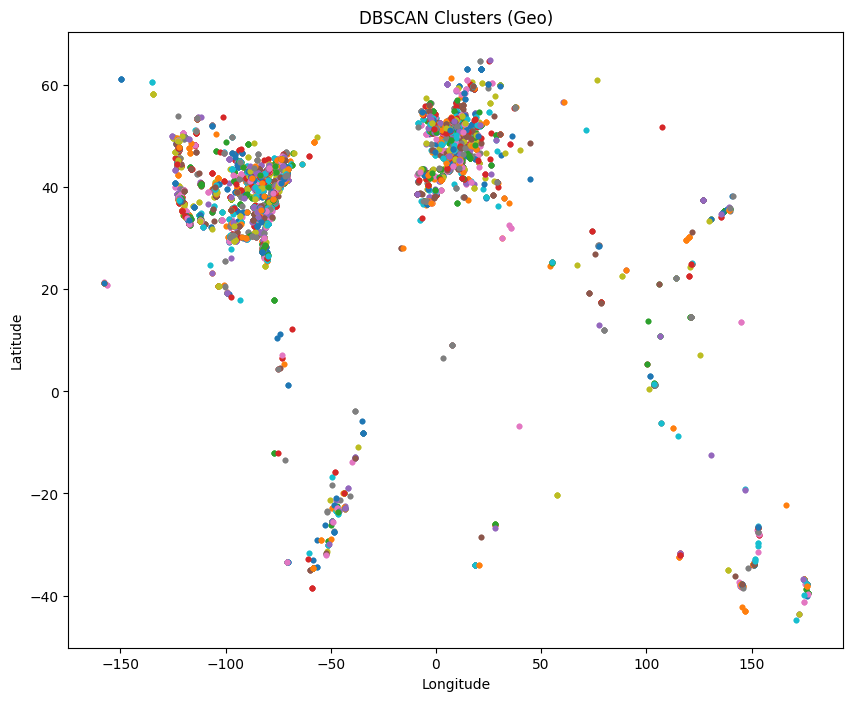

In [88]:
labels = db.labels_
# print(labels)

plt.figure(figsize=(10,8))
unique_labels = set(labels)

for label in unique_labels:
    cluster_points = coord[labels == label]

    if label == -1:
        # label_name = "Noise"
        # color = "black"
        continue # not plotting noise so the graph is cleaner
    else:
        label_name = f"Cluster {label}"
        color = None  # let matplotlib auto-pick colors

    plt.scatter(
        cluster_points[:, 1],
        cluster_points[:, 0],
        s=10,
        label=label_name
    )

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("DBSCAN Clusters (Geo)")
# plt.legend()
plt.show()

In [89]:
reduced_resolution_data.loc[reduced_resolution_data[["main_latitude", "main_longitude"]].notna().all(axis=1), "geo_cluster"] = db.labels_
reduced_resolution_data.head()

,company_name,company_legal_names,company_commercial_names,main_country_code,main_country,main_region,main_city_district,main_city,main_postcode,main_street,main_street_number,main_latitude,main_longitude,main_address_raw_text,num_locations,company_type,year_founded,short_description,long_description,business_tags,business_model,product_type,naics_vertical,naics_2022_primary_code,naics_2022_primary_label,main_business_category,main_industry,main_sector,primary_phone,phone_numbers,primary_email,website_url,website_domain,website_language_code,facebook_url,instagram_url,linkedin_url,sics_codified_industry,sics_codified_industry_code,sics_codified_subsector,sics_codified_subsector_code,sics_codified_sector,sics_codified_sector_code,sic_codes,sic_labels,isic_v4_codes,isic_v4_labels,nace_rev2_codes,nace_rev2_labels,created_at,last_updated_at,website_number_of_pages,generated_description,generated_business_tags,domains,all_domains,revenue,revenue_type,employee_count,employee_count_type,inbound_links_count,original_company_name,geo_cluster
0,owens liquors,None,owens liquors,us,united states,south carolina,None,pawleys island,29585,ocean highway,13707,33.479850,-79.100131,13707 ocean hwy pawleys island sc 29585 united...,1,private,None,owens liquors is a beer and liquor store based...,None,None,retail,nondurable products,beer and liquor stores,445320,beer wine and liquor retailers,beer and liquor stores,beverages,food and beverages,+18433140354,+18433140354,None,https://pawleysisland.owensliquors.com/,owensliquors.com,None,None,None,None,None,None,None,None,None,None,5411 | 5431 | 5142 | 5961 | 5921 | 5961 | 5181...,grocery stores frozen food and freezer plan pr...,4722 | 4781 | 4791 | 4799,retail sale of beverages in specialized stores...,47.91 | 47.25 | 47.81 | 47.99,retail sale via mail order houses or via inter...,2021-11-05 21:06:53,2024-10-23 15:40:49.221,None,owens liquors is a retail establishment locate...,retail trade liquor stores wine and liquor,None,None,None,None,None,None,None,Owens Liquors,-1.0
1,club tarneit,None,club tarneit,au,australia,victoria,tarneit,city of wyndham,3029,None,None,NaN,NaN,tarneit victoria 3029 australia,1,private,None,club tarneit is a dance night club based in ci...,club tarneit experience the difference dive in...,events and service,services,consumer services,None,None,None,dance clubs and night clubs,pubs and bars,accommodation and food services,None,None,None,https://www.clubtarneit.com.au/,clubtarneit.com.au,None,None,None,http://www.linkedin.com/company/club-tarneit,None,None,None,None,None,None,None,None,None,None,None,None,2024-08-17 08:08:55.74,2024-11-23 01:22:57.613,None,None,None,None,None,None,None,9,extracted,None,Club Tarneit,NaN
2,aaa auto otrokovice zlín,None,aaa auto otrokovice zlín,cz,czechia,zlín,kvítkovice u otrokovic,otrokovice,765 02,zlínská,260,49.199304,17.545312,zlínská 260 765 02 otrokovice 2 czechia,1,private,None,aaa auto otrokovice zlín is an automobile deal...,None,None,retail,durable products,automobile dealers and manufacturers,441120,used car dealers,automobile dealers and manufacturers,automobile dealers and manufacturers,automotive,+420800400450,+420800400450,None,https://www.aaaauto.cz/?bsw=251,aaaauto.cz,None,None,None,None,None,None,None,None,None,None,5521,motor vehicle dealers used only,4510,sale of motor vehicles,45.11 | 45.19,sale of cars and light motor vehicles sale of ...,2023-06-30 17:31:17.732,2025-01-03 03:48:34.964,None,aaa auto otrokovice zlín is a car dealership a...,in store shopping investment management servic...,None,None,None,None,None,None,None,AAA Auto Otrokovice Zlín,-1.0
3,gisinger,gisinger,None,de,germany,baden württemberg,None,ühlingen birkendorf,79777,berauer straße,19,47.713480,8.285151,19 berauer strasse uhlingen birkendorf baden w...,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,http://www.linkedin.com/company/gisinger-gmbh,None,None,None,None,None,None,None,None,None

In [90]:
# Seeing if the 2 phone_number columns actually bring any new information
reduced_resolution_data[reduced_resolution_data["primary_phone"].fillna("NA") != reduced_resolution_data["phone_numbers"].fillna("NA")]

,company_name,company_legal_names,company_commercial_names,main_country_code,main_country,main_region,main_city_district,main_city,main_postcode,main_street,main_street_number,main_latitude,main_longitude,main_address_raw_text,num_locations,company_type,year_founded,short_description,long_description,business_tags,business_model,product_type,naics_vertical,naics_2022_primary_code,naics_2022_primary_label,main_business_category,main_industry,main_sector,primary_phone,phone_numbers,primary_email,website_url,website_domain,website_language_code,facebook_url,instagram_url,linkedin_url,sics_codified_industry,sics_codified_industry_code,sics_codified_subsector,sics_codified_subsector_code,sics_codified_sector,sics_codified_sector_code,sic_codes,sic_labels,isic_v4_codes,isic_v4_labels,nace_rev2_codes,nace_rev2_labels,created_at,last_updated_at,website_number_of_pages,generated_description,generated_business_tags,domains,all_domains,revenue,revenue_type,employee_count,employee_count_type,inbound_links_count,original_company_name,geo_cluster
14,centro de dia quimey gral,None,centro de dia quimey gral centro de día quim...,ar,argentina,buenos aires,None,ituzaingó,1713,correa,2420,-34.665027,-58.683088,gral correa 2420 ituzaingó provincia de buenos...,2,private,None,centro de dia quimey co gral is a senior care ...,ofrecemos servicios para las personas con disc...,None,services,consumer services,senior care and assisted living facilities,624120,services for the elderly and persons with disa...,senior care and assisted living facilities,social services,health care and social assistance,+541147934076,+541167127827 | +541147536455 | +541151979010 ...,rrhh@centrosquimeyco.com.ar,https://centrosquimeyco.com.ar/,centrosquimeyco.com.ar,es,None,https://www.instagram.com/centrodediaquimeyco....,None,education,sv-ed,consumer services,sv.3,services,sv,8322,individual and family social services services...,8810,social work activities without accommodation f...,88.1,social work activities without accommodation f...,2023-07-29 12:12:31,2024-11-03 15:45:27,9,quimeyco legally known as centro educativo ter...,occupational therapy therapy services care and...,centrosquimeyco com ar,centrosquimeyco com ar,680391,modelled,75,modelled,9,CENTRO DE DIA QUIMEY CO Gral,-1.0
37,rspca radcliffe on trent animal centre,None,rspca radcliffe on trent animal centre rspca r...,gb,united kingdom,england,radcliffe on trent,nottingham,ng12 2dw,nottingham road,32,52.950684,-0.959108,32 nottingham road radcliffe on trent nottingh...,1,private,1963,rspca radcliffe on trent animal centre is an a...,our mission is to rescue rehabilitate and reho...,adopting a pet cat friendly adopting a dog ado...,non profit,non profit,animal preservation and wildlife control,813312,environment conservation and wildlife organiza...,animal shelters,ngos,non profit,+441158550222,+441158550222 | +441636551723 | +443001234999 ...,info@rspca-radcliffe.org.uk,https://rspca-radcliffe.org.uk/,rspca-radcliffe.org.uk,en,https://www.facebook.com/rspcaradcliffeanimalc...,https://www.instagram.com/officialrspcaradcliffe/,None,health care delivery,hc-dy,health care providers,hc.3,health care,hc,8399 | 8699,social services nec environment conservation a...,9499,activities of other membership organizations n...,94.99,activities of other membership organisations n...,2020-04-21 05:46:21,2024-12-15 07:29:17,41,rspca radcliffe animal centre is a registered ...,adoption rooms for rescue dogs legal assistanc...,rspca radcliffe org uk,rspca radcliffe org uk,None,None,None,None,41,RSPCA Radcliffe-on-Trent Animal Centre,-1.0
42,fid demenagement,None,fid demenagement france inter déménagements,fr,france,None,None,None,None,None,None,NaN,NaN,None,1,private,1970,fid demenagement is a movers and heavy transpo...,france inter déménagements est une entreprise ...,None,services,professional services,movers and heavy transportation,484210,used household and office goods moving,movers and heavy transportation,freight transport

### Intra Cluster Comparisons

- comparing records in their assigned clusters by their most unique attributes => phone_number, website domain, company_name

In [91]:
# Comparing records within the same cluster - based on phone number and company name and scoring them
# Creating a graph to hold the indexes of the possible duplicates in order to create a new column for the dataframe and
# easily identify which records might be identical

graph = nx.Graph()
graph.add_nodes_from(reduced_resolution_data.index)

for cluster_id, group in reduced_resolution_data.groupby("geo_cluster"):
  if cluster_id == -1:
    continue

  if len(group) < 2:
    continue # there are not enough records to be duplicates

  for (idx1, rec1), (idx2, rec2) in combinations(group.iterrows(), 2):
    score = 0

    if rec1["primary_phone"] == rec2["primary_phone"]:
      score += 0.5

    if rec1["website_domain"] == rec2["website_domain"]:
      score += 0.15

    # company_name_sim = jaro_Winkler(rec1[1]["company_name"], rec2[1]["company_name"]) # implemented function
    company_name_sim = jaro_winkler(rec1["company_name"], rec2["company_name"]) # from textdistance
    if company_name_sim > 0.8:
      score += 0.35

    if company_name_sim >= 0.7:
      graph.add_edge(idx1, idx2)

In [92]:
reduced_resolution_data["is_duplicated"] = 0
reduced_resolution_data["is_duplicated_with"] = [[] for _ in range(len(reduced_resolution_data))]

for group in nx.connected_components(graph):
  if len(group) > 1:
    group_list = list(group)

    for idx in group_list:
      reduced_resolution_data.at[idx, "is_duplicated"] = 1 # if there are indexes in the graph, it means the records are deemed to be duplicated

      # Only write the indexes of the duplicated records, ignoring the current index of the record
      matches = [match_index for match_index in group_list if match_index != idx]
      reduced_resolution_data.at[idx, "is_duplicated_with"] = matches

In [93]:
reduced_resolution_data[reduced_resolution_data["is_duplicated"] == 1]

,company_name,company_legal_names,company_commercial_names,main_country_code,main_country,main_region,main_city_district,main_city,main_postcode,main_street,main_street_number,main_latitude,main_longitude,main_address_raw_text,num_locations,company_type,year_founded,short_description,long_description,business_tags,business_model,product_type,naics_vertical,naics_2022_primary_code,naics_2022_primary_label,main_business_category,main_industry,main_sector,primary_phone,phone_numbers,primary_email,website_url,website_domain,website_language_code,facebook_url,instagram_url,linkedin_url,sics_codified_industry,sics_codified_industry_code,sics_codified_subsector,sics_codified_subsector_code,sics_codified_sector,sics_codified_sector_code,sic_codes,sic_labels,isic_v4_codes,isic_v4_labels,nace_rev2_codes,nace_rev2_labels,created_at,last_updated_at,website_number_of_pages,generated_description,generated_business_tags,domains,all_domains,revenue,revenue_type,employee_count,employee_count_type,inbound_links_count,original_company_name,geo_cluster,is_duplicated,is_duplicated_with
3,gisinger,gisinger,None,de,germany,baden württemberg,None,ühlingen birkendorf,79777,berauer straße,19,47.713480,8.285151,19 berauer strasse uhlingen birkendorf baden w...,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,http://www.linkedin.com/company/gisinger-gmbh,None,None,None,None,None,None,None,None,None,None,None,None,2024-07-24 12:13:08.98,2024-07-24 12:13:08.98,None,None,None,None,None,None,None,None,None,None,Gisinger GmbH,0.0,1,"[11944, 18619, 5547]"
8,dental planet manukau,None,dental planet manukau,nz,new zealand,auckland,None,auckland,2104,bakerfield place,11e,-36.989383,174.885087,11e bakerfield place manukau city centre auckl...,1,private,None,dental planet manukau is a dentists and dental...,we pair a passion for excellent service with t...,None,services,consumer services,dentist,621210,offices of dentists,dentists and dental clinics,dentists and dental clinics,health care and social assistance,+648002622208,+648002622208,None,https://dentalplanet.co.nz/,dentalplanet.co.nz,None,https://www.facebook.com/dentalplanetnz/,None,None,None,None,None,None,None,None,8021,offices and clinics of dentists,8620,medical and dental practice activities,86.22 | 86.23 | 86.21,specialist medical practice activities dental ...,2021-11-05 19:55:31,2024-08-15 14:16:42.823,None,dental planet manukau is a dental clinic locat...,healthcare services ddental care services,None,None,None,None,None,None,None,Dental Planet Manukau,1.0,1,"[25708, 15800]"
10,piermarq,None,piermarq,au,australia,new south wales,surry hills,sydney,2010,foster street,23 25,-33.879783,151.209924,23 foster st surry hills nsw 2010 australia,1,private,None,piermarq is an art gallery based in sydney aus...,piermarq is a contemporary art gallery in surr...,None,retail,durable products,art galleries,459920,art dealers,art galleries,other durable products,other durable products,+61291888933,+61291888933,None,https://www.piermarq.com.au/,piermarq.com.au,None,https://www.facebook.com/piermarqart/,https://www.instagram.com/piermarqart/,https://au.linkedin.com/company/piermarq-art,None,None,None,None,None,None,5431 | 5961 | 5142 | 5963 | 5421 | 5999 | 5961...,fruit and vegetable markets temporary fruit an...,4773 | 4789 | 4791 | 4799,other retail sale of new goods in specialized ...,47.76 | 47.77 | 47.78 | 47.99 | 47.89 | 47.91,retail sale of flowers plants seeds fertiliser...,2021-10-01 19:53:10,2024-08-26 17:30:41.767,None,piermarq is an organization based in sydney au...,arts administration services museum services b...,None,None,None,None,None,None,None,PIERMARQ,3.0,1,"[4432, 5417, 21452]"
22,andrea veramonti design studio,None,andrea veramonti design studio,it,italy,marche,santa croce,macerata,62100,via roma,279,43.298488,13.438745,279 via roma macerata marche 62100 italy,1,private,2021,andrea veramonti design studio is a graphic de...,who i am art

In [94]:
# Manually checking some resulting records

# reduced_resolution_data.loc[[23, 24239]]
# reduced_resolution_data.loc[[33440, 20578, 22889, 25044, 29556, 29468, 6079]]
reduced_resolution_data.loc[[33427, 25172, 25862]]

,company_name,company_legal_names,company_commercial_names,main_country_code,main_country,main_region,main_city_district,main_city,main_postcode,main_street,main_street_number,main_latitude,main_longitude,main_address_raw_text,num_locations,company_type,year_founded,short_description,long_description,business_tags,business_model,product_type,naics_vertical,naics_2022_primary_code,naics_2022_primary_label,main_business_category,main_industry,main_sector,primary_phone,phone_numbers,primary_email,website_url,website_domain,website_language_code,facebook_url,instagram_url,linkedin_url,sics_codified_industry,sics_codified_industry_code,sics_codified_subsector,sics_codified_subsector_code,sics_codified_sector,sics_codified_sector_code,sic_codes,sic_labels,isic_v4_codes,isic_v4_labels,nace_rev2_codes,nace_rev2_labels,created_at,last_updated_at,website_number_of_pages,generated_description,generated_business_tags,domains,all_domains,revenue,revenue_type,employee_count,employee_count_type,inbound_links_count,original_company_name,geo_cluster,is_duplicated,is_duplicated_with
33427,bawarrion,None,bawarrion bawarrion since 2013,us,united states,nevada,None,carson city,89701,north deer run road,3170,39.188122,-119.703463,3170 n deer run road 5 carson city nv 89701,1,private,None,bawarrion is an auto parts manufacturer based ...,order your own bawarrion dtx rack today enhanc...,performance parts wheel accessories winch moun...,manufacturing,durable products,motor vehicle parts manufacturing,336330,motor vehicle steering and suspension componen...,auto parts manufacturers,auto parts,automotive,+18008151525,+18008151525,info@bawarrion.com,https://bawarrion.com/,bawarrion.com,en,https://www.facebook.com/bawarrion/,https://www.instagram.com/bawarrion/,None,multiline and specialty retailers and distribu...,cg-mr,consumer goods retail,cg.3,consumer goods,cg,3714,motor vehicle parts and accessories steering a...,2813 | 2930,manufacture of other pumps compressors taps an...,28.14 | 28.13 | 29.31 | 29.32,manufacture of other taps and valves manufactu...,2019-12-04 11:23:55,2024-07-22 00:52:09,25,bawarrion is a company based in hesperia calif...,dynamically engineered shock valving upgrade k...,bawarrion com,bawarrion com,34588200,modelled,75,modelled,25,BAWARRION,3345.0,1,"[25172, 25862]"
25172,bawarrion,None,bawarrion,us,united states,nevada,None,carson city,89701,north deer run road,3170,39.187660,-119.703916,3170 n deer run rd carson city nv 89701,None,None,None,None,None,None,None,None,None,None,None,None,None,None,+18008151525,+18008151525,None,https://bawarrion.com/contact/,bawarrion.com,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,2024-05-13 02:24:54.983,2024-05-13 04:55:07.118,None,bawarrion is a company based in carson city ne...,wheelchair accessible entrance custom programm...,bawarrion com,bawarrion com,None,None,None,None,None,Bawarrion,3345.0,1,"[33427, 25862]"
25862,bawarrion,None,bawarrion,us,united states,nevada,None,carson city,89701,north deer run road,3170,39.188122,-119.703463,3170 n deer run road 5 6 carson city nevada 89701,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,https://www.bawarrion.com/,bawarrion.com,None,None,https://www.instagram.com/bawarrion/,None,None,None,None,None,None,None,None,None,None,None,None,None,2024-07-21 20:56:07.854,2024-07-21 20:56:07.854,None,None,None,None,None,None,None,None,None,None,Bawarrion,3345.0,1,"[33427, 25172]"


### Unique Companies

- based on the *is_duplicated* and *is_duplicated_with* columns, we get the unique companies from the dataset (the company name is added for the first *created_at* timestamp)

In [95]:
# Sorting the dataframe depending on the created_at column
reduced_resolution_data_sorted = reduced_resolution_data.sort_values(by = "created_at", ascending = True)

# Getting the lowest index in the is_duplicated_with column
# If there are groups with no duplicates - the record gets its own index
reduced_resolution_data_sorted["main_group_idx"] = reduced_resolution_data_sorted.index
duplicate_mask = reduced_resolution_data_sorted["is_duplicated"] == 1

reduced_resolution_data_sorted.loc[duplicate_mask, "main_group_idx"] = reduced_resolution_data_sorted.loc[duplicate_mask, "is_duplicated_with"].apply(lambda x: min(x) if x else None)

# Fall back to its own index if the group has an empty list
# reduced_resolution_data_sorted["main_group_idx"] = reduced_resolution_data_sorted["main_group_idx"].fillna(reduced_resolution_data_sorted.index)

# Getting the unique companies
unique_companies_df = reduced_resolution_data_sorted.drop_duplicates(subset = "main_group_idx", keep = "first")

unique_companies_list = unique_companies_df["original_company_name"].unique().tolist()
print(f"Number of unique companies: {len(unique_companies_list)}")
print(f"Unique companies list: {unique_companies_list}")

Number of unique companies: 17716
Unique companies list: ['SpaceX', 'IGG-AD', 'North Hudson Sewerage Authority', 'Pirracchio', 'RAMBUTIKEN', 'Props Ahoy', "Grandma's House of Hope", 'KFTCU', 'Leilani Tree & Land Services', 'SEHC Foundation', None, 'AMG GROUP MUSIC', 'Repairs by Post', 'Tri-Way Drive-In Theatre', 'JD Sports', 'Viiva', 'WVDOF Region', 'Audiobrain', 'Asian Vivekanand Hospital', 'The Greenberg Law Firm', 'Freestyle Ontario', 'Next Day Plus', "Andre #1's", 'Tedderphoto', 'The State Room Presents', '5 Star cleaning residential', 'Poynt', 'Taos Community Foundation', "Kids Play Int'l", 'PHOENIX MANAGEMENT.', 'AV Computer Repair', 'Brazen Edwards', 'Corporate Images Inc.', 'Tandem Properties', 'Printpal', 'Huebner Funeral Homes', 'FensterBerlins', 'Black Sea Jewelers', 'Stowers. CAT', 'Burg Schwarzenstein', 'PPS EQUIPMENT', 'Chris Harman DMD', 'Fostering North East', 'HYPO NOE', 'Sabertrio', 'Oaksville Laundromat', 'Mooresville Body Shop', "Gahm's Guns", 'Gainsite', 'AUGUST WE

### Grouped Output and Intervals

In [98]:
# Checking if there are still missing values for the datetime columns
reduced_resolution_data_sorted[reduced_resolution_data_sorted["created_at"].isnull()]

# # Ensuring datetime instead of object data type
# reduced_resolution_data_sorted["last_updated_at"] = pd.to_datetime(reduced_resolution_data_sorted["last_updated_at"])
# reduced_resolution_data_sorted["created_at"] = pd.to_datetime(reduced_resolution_data_sorted["created_at"])

,company_name,company_legal_names,company_commercial_names,main_country_code,main_country,main_region,main_city_district,main_city,main_postcode,main_street,main_street_number,main_latitude,main_longitude,main_address_raw_text,num_locations,company_type,year_founded,short_description,long_description,business_tags,business_model,product_type,naics_vertical,naics_2022_primary_code,naics_2022_primary_label,main_business_category,main_industry,main_sector,primary_phone,phone_numbers,primary_email,website_url,website_domain,website_language_code,facebook_url,instagram_url,linkedin_url,sics_codified_industry,sics_codified_industry_code,sics_codified_subsector,sics_codified_subsector_code,sics_codified_sector,sics_codified_sector_code,sic_codes,sic_labels,isic_v4_codes,isic_v4_labels,nace_rev2_codes,nace_rev2_labels,created_at,last_updated_at,website_number_of_pages,generated_description,generated_business_tags,domains,all_domains,revenue,revenue_type,employee_count,employee_count_type,inbound_links_count,original_company_name,geo_cluster,is_duplicated,is_duplicated_with,main_group_idx


In [101]:
# For the processed dataframe, it creates a group index to group duplicates
# If it is a duplicate, the index is the minimum in the network, otherwise the index is its own
reduced_resolution_data["entity_group_idx"] = reduced_resolution_data.index
duplicate_mask = reduced_resolution_data["is_duplicated"] == 1

reduced_resolution_data.loc[duplicate_mask, "entity_group_idx"] = reduced_resolution_data.loc[duplicate_mask, "is_duplicated_with"].apply(lambda x: min(x) if x else None)
# reduced_resolution_data["entity_group_idx"] = reduced_resolution_data["entity_group_idx"].fillna(reduced_resolution_data.index).astype(int)


# Sorting the dataframe by last_updated_at
reduced_resolution_data_sorted = reduced_resolution_data.sort_values(by = "last_updated_at", ascending = True)

#
enriched_grouped_data = (reduced_resolution_data_sorted.groupby("entity_group_idx", group_keys = False).apply(merge_duplicates).sort_index())
enriched_grouped_data.head()

/tmp/ipykernel_20746/2979651481.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  enriched_grouped_data = (reduced_resolution_data_sorted.groupby("entity_group_idx", group_keys = False).apply(merge_duplicates).sort_index())


,company_name,company_legal_names,company_commercial_names,main_country_code,main_country,main_region,main_city_district,main_city,main_postcode,main_street,main_street_number,main_latitude,main_longitude,main_address_raw_text,num_locations,company_type,year_founded,short_description,long_description,business_tags,business_model,product_type,naics_vertical,naics_2022_primary_code,naics_2022_primary_label,main_business_category,main_industry,main_sector,primary_phone,phone_numbers,primary_email,website_url,website_domain,website_language_code,facebook_url,instagram_url,linkedin_url,sics_codified_industry,sics_codified_industry_code,sics_codified_subsector,sics_codified_subsector_code,sics_codified_sector,sics_codified_sector_code,sic_codes,sic_labels,isic_v4_codes,isic_v4_labels,nace_rev2_codes,nace_rev2_labels,created_at,last_updated_at,website_number_of_pages,generated_description,generated_business_tags,domains,all_domains,revenue,revenue_type,employee_count,employee_count_type,inbound_links_count,original_company_name,geo_cluster,is_duplicated,is_duplicated_with,entity_group_idx
0,owens liquors,None,owens liquors,us,united states,south carolina,None,pawleys island,29585,ocean highway,13707,33.479850,-79.100131,13707 ocean hwy pawleys island sc 29585 united...,1,private,None,owens liquors is a beer and liquor store based...,None,None,retail,nondurable products,beer and liquor stores,445320,beer wine and liquor retailers,beer and liquor stores,beverages,food and beverages,+18433140354,+18433140354,None,https://pawleysisland.owensliquors.com/,owensliquors.com,None,None,None,None,None,None,None,None,None,None,5411 | 5431 | 5142 | 5961 | 5921 | 5961 | 5181...,grocery stores frozen food and freezer plan pr...,4722 | 4781 | 4791 | 4799,retail sale of beverages in specialized stores...,47.91 | 47.25 | 47.81 | 47.99,retail sale via mail order houses or via inter...,2021-11-05 21:06:53,2024-10-23 15:40:49.221,None,owens liquors is a retail establishment locate...,retail trade liquor stores wine and liquor,None,None,None,None,None,None,None,Owens Liquors,-1.0,0,[],0
1,club tarneit,None,club tarneit,au,australia,victoria,tarneit,city of wyndham,3029,None,None,NaN,NaN,tarneit victoria 3029 australia,1,private,None,club tarneit is a dance night club based in ci...,club tarneit experience the difference dive in...,events and service,services,consumer services,None,None,None,dance clubs and night clubs,pubs and bars,accommodation and food services,None,None,None,https://www.clubtarneit.com.au/,clubtarneit.com.au,None,None,None,http://www.linkedin.com/company/club-tarneit,None,None,None,None,None,None,None,None,None,None,None,None,2024-08-17 08:08:55.74,2024-11-23 01:22:57.613,None,None,None,None,None,None,None,9,extracted,None,Club Tarneit,NaN,0,[],1
2,aaa auto otrokovice zlín,None,aaa auto otrokovice zlín,cz,czechia,zlín,kvítkovice u otrokovic,otrokovice,765 02,zlínská,260,49.199304,17.545312,zlínská 260 765 02 otrokovice 2 czechia,1,private,None,aaa auto otrokovice zlín is an automobile deal...,None,None,retail,durable products,automobile dealers and manufacturers,441120,used car dealers,automobile dealers and manufacturers,automobile dealers and manufacturers,automotive,+420800400450,+420800400450,None,https://www.aaaauto.cz/?bsw=251,aaaauto.cz,None,None,None,None,None,None,None,None,None,None,5521,motor vehicle dealers used only,4510,sale of motor vehicles,45.11 | 45.19,sale of cars and light motor vehicles sale of ...,2023-06-30 17:31:17.732,2025-01-03 03:48:34.964,None,aaa auto otrokovice zlín is a car dealership a...,in store shopping investment management servic...,None,None,None,None,None,None,None,AAA Auto Otrokovice Zlín,-1.0,0,[],2
3,gisinger,gisinger,None,de,germany,baden württemberg,None,ühlingen birkendorf,79777,berauer straße,19,47.713480,8.285151,19 berauer strasse uhlingen birkendorf baden w...,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,http://www.linkedin

In [103]:
# Creating a dataframe for the historical changes based on last_updated_at column
historical_data = reduced_resolution_data[reduced_resolution_data["is_duplicated"] == 1].sort_values(by = ["entity_group_idx", "last_updated_at"])
historical_data.head()

,company_name,company_legal_names,company_commercial_names,main_country_code,main_country,main_region,main_city_district,main_city,main_postcode,main_street,main_street_number,main_latitude,main_longitude,main_address_raw_text,num_locations,company_type,year_founded,short_description,long_description,business_tags,business_model,product_type,naics_vertical,naics_2022_primary_code,naics_2022_primary_label,main_business_category,main_industry,main_sector,primary_phone,phone_numbers,primary_email,website_url,website_domain,website_language_code,facebook_url,instagram_url,linkedin_url,sics_codified_industry,sics_codified_industry_code,sics_codified_subsector,sics_codified_subsector_code,sics_codified_sector,sics_codified_sector_code,sic_codes,sic_labels,isic_v4_codes,isic_v4_labels,nace_rev2_codes,nace_rev2_labels,created_at,last_updated_at,website_number_of_pages,generated_description,generated_business_tags,domains,all_domains,revenue,revenue_type,employee_count,employee_count_type,inbound_links_count,original_company_name,geo_cluster,is_duplicated,is_duplicated_with,entity_group_idx
5547,gisinger,gisinger,None,de,germany,baden württemberg,None,ühlingen birkendorf,79777,berauer straße,19,47.713480,8.285151,19 berauer strasse uhlingen birkendorf baden w...,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,https://www.gisinger-gmbh.de/,gisinger-gmbh.de,None,None,None,http://www.linkedin.com/company/gisinger-gmbh,None,None,None,None,None,None,None,None,None,None,None,None,2024-07-26 18:01:54.2,2024-08-07 01:39:45.316,None,None,None,None,None,None,None,None,None,None,Gisinger GmbH,0.0,1,"[11944, 3, 18619]",3
18619,gisinger,gisinger,None,de,germany,baden württemberg,None,ühlingen birkendorf,79777,berauer straße,19,47.713480,8.285151,19 berauer strasse uhlingen birkendorf baden w...,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,https://www.gisinger-gmbh.de/,gisinger-gmbh.de,None,None,None,http://www.linkedin.com/company/gisinger-gmbh,None,None,None,None,None,None,None,None,None,None,None,None,2024-11-11 11:09:42.068,2024-11-11 11:09:42.068,None,None,None,None,None,None,None,None,None,None,Gisinger GmbH,0.0,1,"[11944, 3, 5547]",3
11944,gisinger,gisinger,None,de,germany,baden württemberg,None,ühlingen birkendorf,79777,berauer straße,19,47.713550,8.285160,berauer str 19 79777 ühlingen birkendorf germany,1,private,None,gisinger gmbh is a taxicab services company ba...,None,None,services,professional services,taxicabs,485310,taxi and ridesharing services,taxicabs,passenger transport services,transport and warehousing,+497743213,+497743213,None,None,None,None,None,None,None,None,None,None,None,None,None,4899 | 4121,communications services nec radio broadcasting...,4922 | 5221,other passenger land transport service activit...,52.21 | 49.39 | 49.32,service activities incidental to land transpor...,2023-07-10 13:49:53.113,2024-12-29 11:26:41.852,None,gisinger gmbh is a taxi service company based ...,wheelchair parking transportation services,None,None,None,None,None,None,None,Gisinger GmbH,0.0,1,"[3, 18619, 5547]",3
25708,dental planet,None,dental planet,nz,new zealand,auckland,None,auckland,2104,bakerfield place,11e,-36.989384,174.885089,11e bakerfield pl auckland auckland 2104 new z...,1,private,2021,dental planet is a dentists and dental clinic ...,at dental planet we are providing you with a l...,hospital care health care and hospital,services,consumer services,dentist,621210,offices of dentists,dentists and dental clinics,dentists and dental clinics,health care and social assistance,+648002622208,+648002622208,None,https://www.dentalplanet.co.nz/,dentalplanet.co.nz,None,https://www.facebook.com/dentalplanetnz,https://www.instagram.com/dentalplanetnz/,http://www.linkedin.com/company/dental-planet-nz,None,None,None,None,None,None,8021,offices and clinics of dentists,8620,medical and dental practice activities,86.22 | 86.23 | 86.21,specialist medical practice activitie

In [104]:
# Saving the final dataframes to csv files

enriched_grouped_data.to_csv("grouped_data.csv", index=False)
historical_data.to_csv("historical_data.csv", index=False)